In [4]:
# ================================================================
# System & Utility Libraries
# ================================================================
import os
import re
import tempfile
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")  # suppress non-critical warnings

# ================================================================
# Data Manipulation & Visualization
# ================================================================
import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import seaborn as sns

# ================================================================
# Financial & Macroeconomic Data Access (optional)
# ================================================================
try:
    import yfinance as yf
except Exception:
    yf = None

try:
    from pandas_datareader import data as web
except Exception:
    web = None

# ================================================================
# Machine Learning Models
# ================================================================
from sklearn.decomposition import PCA
from sklearn.ensemble import (
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    RandomForestRegressor
)
from sklearn.linear_model import (
    ElasticNet,
    LinearRegression,
    Ridge
)
from sklearn.mixture import GaussianMixture
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# --- Boosting Libraries ---
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# ================================================================
# Model Selection & Evaluation
# ================================================================
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    TimeSeriesSplit,
    cross_val_score,
    train_test_split
)
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
    roc_auc_score
)
from scipy.stats import pearsonr

# ================================================================
# Time Series & Statistical Tools
# ================================================================
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ================================================================
# Imbalanced Data Handling (optional)
# ================================================================
try:
    from imblearn.over_sampling import SMOTE
except Exception:
    SMOTE = None

# ================================================================
# Model Explainability (optional)
# ================================================================
try:
    import shap
except Exception:
    shap = None

# ================================================================
# NLP: Sentiment Extraction (FinBERT)
# ================================================================
os.environ["TOKENIZERS_PARALLELISM"] = "false"  # avoid tokenizer warnings
try:
    import torch
    import torch.nn.functional as F
    from transformers import AutoModelForSequenceClassification, AutoTokenizer
except Exception:
    torch = None
    F = None
    AutoModelForSequenceClassification = None
    AutoTokenizer = None

# ================================================================
# PDF, Web Scraping & HTML Parsing (optional)
# ================================================================
try:
    import requests
except Exception:
    requests = None

try:
    import pdfplumber
except Exception:
    pdfplumber = None

try:
    from bs4 import BeautifulSoup
except Exception:
    BeautifulSoup = None

# ================================================================
# Notebook Display Utilities
# ================================================================
from IPython.display import display, Markdown

In [2]:
# Claim all the folders used
project_directory =   "/Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject"
scripts_directory =   "/Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Scripts"
macro_directory =     "/Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Data/macro"
beigebook_directory = "/Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Data/beigebook"
manual_directory = "/Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Data/manual"
model_directory =     "/Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Models"
results_directory =   "/Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Results"

In [21]:
# Define the path to the final file
cleaned_subfolder = os.path.join(beigebook_directory, "cleaned_full")
final_df_csv_path = os.path.join(cleaned_subfolder, "final_df.csv")

# Read the CSV into a DataFrame
final_df = pd.read_csv(final_df_csv_path, index_col=0, parse_dates=True)

# Preview
print(final_df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 248 entries, 2003-01-01 to 2023-08-01
Data columns (total 24 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   CPI                                248 non-null    float64
 1   INDPRO                             248 non-null    float64
 2   VIX                                248 non-null    float64
 3   T10YIE                             248 non-null    float64
 4   GS10                               248 non-null    float64
 5   SP500                              248 non-null    float64
 6   TLT                                248 non-null    float64
 7   Inflation_Uncertainty_10y          248 non-null    float64
 8   Inflation_10y                      248 non-null    float64
 9   Real_Yield_10y                     248 non-null    float64
 10  INDPRO_YoY_Growth                  248 non-null    float64
 11  SP500_TLT_Corr_24m_fl              248 

In [23]:
# Drop all sentence-based sentiment columns and update final_df in place
final_df = final_df.drop(columns=[col for col in final_df.columns if 'sentiment_sentence' in col])

# Preview
print(final_df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 248 entries, 2003-01-01 to 2023-08-01
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CPI                        248 non-null    float64
 1   INDPRO                     248 non-null    float64
 2   VIX                        248 non-null    float64
 3   T10YIE                     248 non-null    float64
 4   GS10                       248 non-null    float64
 5   SP500                      248 non-null    float64
 6   TLT                        248 non-null    float64
 7   Inflation_Uncertainty_10y  248 non-null    float64
 8   Inflation_10y              248 non-null    float64
 9   Real_Yield_10y             248 non-null    float64
 10  INDPRO_YoY_Growth          248 non-null    float64
 11  SP500_TLT_Corr_24m_fl      248 non-null    float64
 12  sentiment                  248 non-null    float64
 13  sentiment_lag_1m           247 

In [25]:
print(final_df.head())
print(final_df.tail())

              CPI   INDPRO        VIX    T10YIE  GS10       SP500        TLT  \
date                                                                           
2003-01-01  182.6  91.1369  27.424286  1.754286  4.05  855.700012  41.223919   
2003-02-01  183.6  91.2505  32.218421  1.912632  3.90  841.150024  42.500748   
2003-03-01  183.9  91.0006  30.634286  1.862857  3.81  848.179993  41.920738   
2003-04-01  183.2  90.4311  23.991905  1.774762  3.96  916.919983  42.360195   
2003-05-01  182.9  90.4000  20.239524  1.660952  3.57  963.590027  45.037216   

            Inflation_Uncertainty_10y  Inflation_10y  Real_Yield_10y  \
date                                                                   
2003-01-01                   0.006598       0.024890        2.295714   
2003-02-01                   0.006590       0.025235        1.987368   
2003-03-01                   0.006590       0.025259        1.947143   
2003-04-01                   0.006570       0.024511        2.185238   
2003-05

## Regime Classification

### Purpose  
Regime classification is introduced to identify **distinct macroeconomic environments** such as expansion, tightening, crisis, or recovery that influence how stocks and bonds interact.  
This step follows the two-stage framework from **Wu et al. (2022)**, where regime identification precedes correlation forecasting, allowing the second-stage model to adapt to different market conditions.

### Included Variables  
The following 11 features are used for regime classification:  
`CPI`, `INDPRO`, `VIX`, `T10YIE`, `GS10`, `SP500`, `TLT`,  
`Inflation_Uncertainty_10y`, `Inflation_10y`, `Real_Yield_10y`, `INDPRO_YoY_Growth`.

### Rationale  
These features capture key dimensions of the macro-financial environment:  
- **Inflation and Interest Rates:** Long-term inflation expectations and real yields.  
- **Market Risk and Returns:** Stock (`SP500`), bond (`TLT`), and volatility (`VIX`) indicators.  
- **Economic Activity:** `CPI` and `INDPRO` reflect consumption and production dynamics.  
- **Uncertainty and Growth:** `Inflation_Uncertainty_10y` and `INDPRO_YoY_Growth` capture volatility and economic momentum.

### Excluded Variables  
- **Sentiment features:** Excluded to avoid model-driven bias; sentiment will be added later to test its incremental value.  
- **Target variable (`SP500_TLT_Corr_24m_fl`):** Excluded to prevent lookahead bias.

### Why Add Regime Classification  
- Enables the model to **recognize structural breaks** and changing relationships in financial markets.  
- Provides a **context-aware foundation** for correlation forecasting, improving stability and interpretability.  
- Ensures the second-stage model (e.g., Gradient Boosting) learns within **economically coherent regimes** rather than mixing data across cycles.

### Key Takeaway  
> Regime classification enhances forecasting by embedding **economic context** directly into the model pipeline helping distinguish how macro factors drive stock–bond dynamics under different market regimes.

In [29]:
# Define regime features (exclude sentiment and target)
regime_features = [
    col for col in final_df.columns
    if not col.startswith('sentiment') and col != 'SP500_TLT_Corr_24m_fl'
]

# Subset and drop missing
X_regime = final_df[regime_features].dropna()

# Preview
print(X_regime.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 248 entries, 2003-01-01 to 2023-08-01
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CPI                        248 non-null    float64
 1   INDPRO                     248 non-null    float64
 2   VIX                        248 non-null    float64
 3   T10YIE                     248 non-null    float64
 4   GS10                       248 non-null    float64
 5   SP500                      248 non-null    float64
 6   TLT                        248 non-null    float64
 7   Inflation_Uncertainty_10y  248 non-null    float64
 8   Inflation_10y              248 non-null    float64
 9   Real_Yield_10y             248 non-null    float64
 10  INDPRO_YoY_Growth          248 non-null    float64
dtypes: float64(11)
memory usage: 23.2 KB
None


In [38]:
print(X_regime.head(2))
print(X_regime.tail(2))

              CPI   INDPRO        VIX    T10YIE  GS10       SP500        TLT  \
date                                                                           
2003-01-01  182.6  91.1369  27.424286  1.754286  4.05  855.700012  41.223919   
2003-02-01  183.6  91.2505  32.218421  1.912632  3.90  841.150024  42.500748   

            Inflation_Uncertainty_10y  Inflation_10y  Real_Yield_10y  \
date                                                                   
2003-01-01                   0.006598       0.024890        2.295714   
2003-02-01                   0.006590       0.025235        1.987368   

            INDPRO_YoY_Growth  
date                           
2003-01-01           0.030222  
2003-02-01           0.031571  
                CPI    INDPRO        VIX    T10YIE  GS10        SP500  \
date                                                                    
2023-07-01  304.615  103.0722  13.932381  2.296500  3.90  4588.959961   
2023-08-01  306.138  103.0951  15.853913  2

## Approach 1: Detect Multicollinearity
### Multicollinearity occurs when two or more features are highly linearly correlated, making them redundant and potentially distorting model behavior.

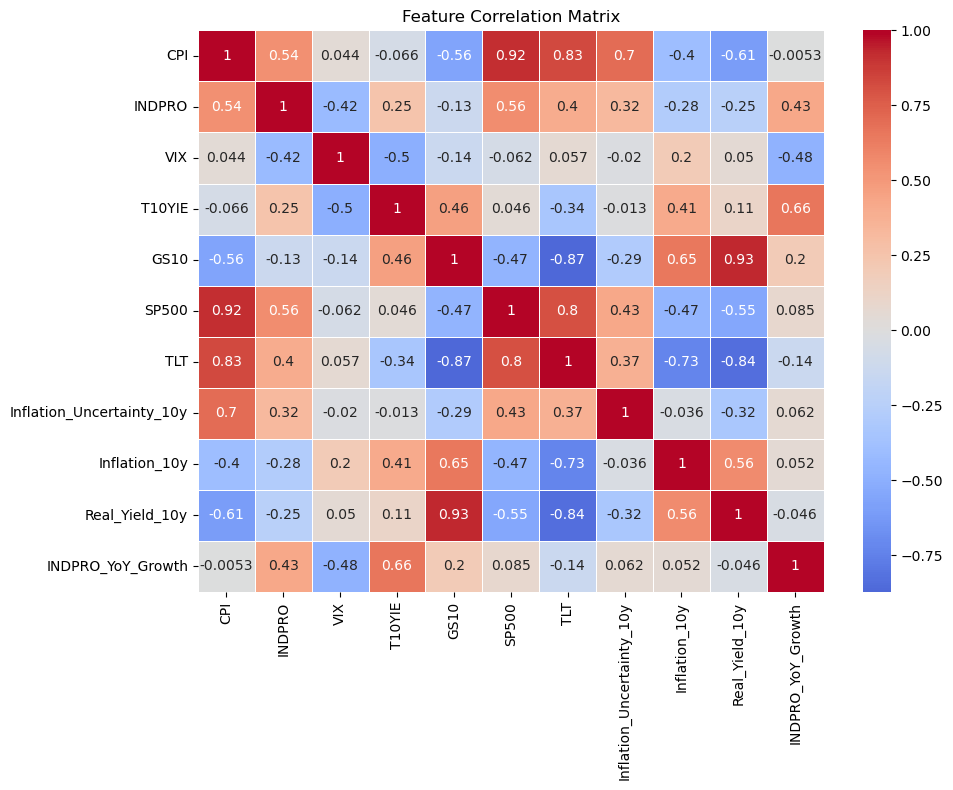

In [40]:
# Compute correlation matrix
corr_matrix = X_regime.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

### Feature Pruning Before Clustering

**Goal:**  
To reduce redundancy and avoid multicollinearity before regime classification, a correlation heatmap was analyzed among all macroeconomic variables (excluding the target).

---

#### Observed Strong Correlations
| Feature Pair | Correlation | Interpretation |
|---------------|--------------|----------------|
| **CPI – SP500** | **0.92** | Reflects overlapping inflation–market level behavior. |
| **CPI – TLT** | **0.83** | High but economically meaningful; represents inflation–bond price inverse relationship. |
| **SP500 – TLT** | **0.80** | Risk-on/risk-off pattern; equities and bonds move inversely. |
| **GS10 – Real_Yield_10y** | **0.93** | Redundant yield measures; both describe similar long-term interest rate dynamics. |
| **CPI – Inflation_Uncertainty_10y** | **0.70** | Moderate correlation; reflects stable vs. uncertain inflation expectations. |

---

#### Feature Selection Decision
- **Dropped:** `SP500`, `GS10` — due to strong redundancy with CPI and T10YIE/Real_Yield_10y.  
- **Retained:**  
  - `CPI` — core inflation measure.  
  - `TLT` — captures bond market and risk sentiment.  
  - `Inflation_Uncertainty_10y` — provides unique inflation risk information.

In [43]:
# Feature Pruning Before Clustering
features_to_drop = ['SP500', 'GS10']
X_selected = X_regime.drop(columns=features_to_drop)

print(X_selected.info())
print(X_selected.tail(2))

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 248 entries, 2003-01-01 to 2023-08-01
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CPI                        248 non-null    float64
 1   INDPRO                     248 non-null    float64
 2   VIX                        248 non-null    float64
 3   T10YIE                     248 non-null    float64
 4   TLT                        248 non-null    float64
 5   Inflation_Uncertainty_10y  248 non-null    float64
 6   Inflation_10y              248 non-null    float64
 7   Real_Yield_10y             248 non-null    float64
 8   INDPRO_YoY_Growth          248 non-null    float64
dtypes: float64(9)
memory usage: 19.4 KB
None
                CPI    INDPRO        VIX    T10YIE        TLT  \
date                                                            
2023-07-01  304.615  103.0722  13.932381  2.296500  91.971794   
2023-08-01  306.138 

In [45]:
# Standardize Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

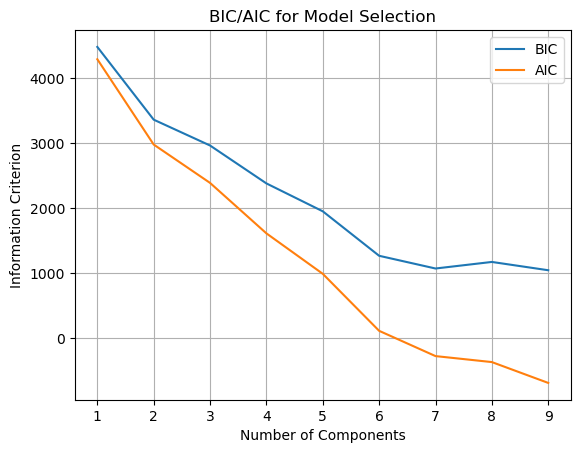

In [47]:
n_components_range = range(1, 10)
bics = []
aics = []

for n in n_components_range:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X_scaled)
    bics.append(gmm.bic(X_scaled))
    aics.append(gmm.aic(X_scaled))

plt.plot(n_components_range, bics, label='BIC')
plt.plot(n_components_range, aics, label='AIC')
plt.xlabel('Number of Components')
plt.ylabel('Information Criterion')
plt.title('BIC/AIC for Model Selection')
plt.legend()
plt.grid(True)
plt.show()

### Model Selection Summary (BIC/AIC Analysis)

- Both BIC and AIC scores decrease sharply between 1 and 5 components, indicating strong gains in model fit.
- Around **6 components**, the BIC curve begins to flatten, suggesting the model has reached an optimal complexity–fit balance.
- Beyond 6, AIC continues to decline slightly, but this improvement likely reflects overfitting rather than meaningful new structure.
- **Selected model:** Gaussian Mixture with **6 regimes** (captures key macroeconomic states while maintaining generalizability).

In [77]:
# Fit a Clustering Model for Regime Labels
gmm = GaussianMixture(n_components=6, random_state=42)
regime_labels = gmm.fit_predict(X_scaled)
X_regime.loc[:, 'Regime_GMM'] = regime_labels

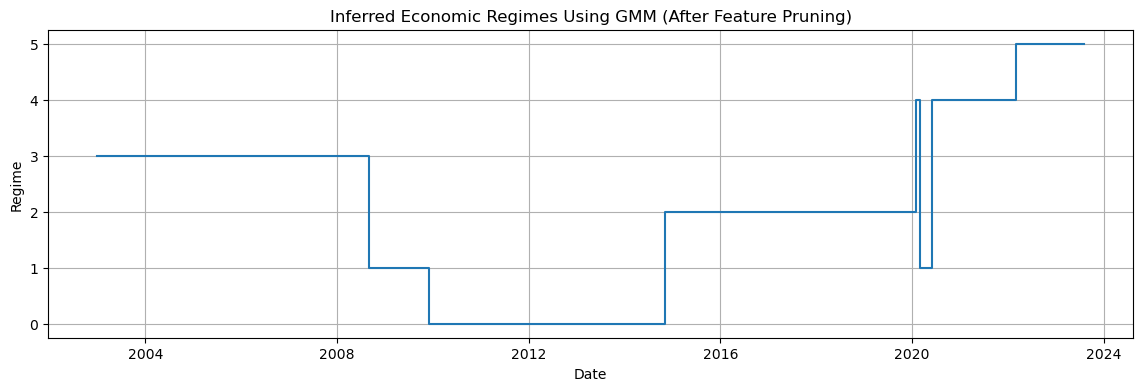

In [79]:
# Plot Regime Transitions Over Time
plt.figure(figsize=(14, 4))
plt.plot(X_regime.index, X_regime['Regime_GMM'], drawstyle='steps-post')
plt.title('Inferred Economic Regimes Using GMM (After Feature Pruning)')
plt.xlabel('Date')
plt.ylabel('Regime')
plt.grid(True)
plt.show()

### Economic Regime Summary (Based on 6-Regime GMM + PCA)
| Period | Regime | Interpretation |
|:-------|:-------|:----------------|
| 2003–2007 | 3 | Pre-crisis expansion with moderate inflation and rising yields. |
| 2008–2010 | 1 | Global Financial Crisis, deflationary pressure, and policy easing. |
| 2011–2015 | 0 | Recovery and QE-driven low-rate environment. |
| 2016–2019 | 2 | Stable growth, low volatility, and tightening cycle. |
| 2020–2022 | 4 | COVID-19 disruption, near-zero rates, and risk-off sentiment. |
| 2022–Now | 5 | Inflation resurgence and rapid monetary tightening. |

## Approach 2: PCA-Based Regime Classification with VIF Filtering and Rolling Diagnostics

This approach refines the regime classification process by first removing highly collinear features using **Variance Inflation Factor (VIF)**, ensuring each macro indicator contributes unique information.  
Next, **Principal Component Analysis (PCA)** is applied on z-scaled features to reduce dimensionality and capture dominant macroeconomic factors driving regime changes.  
Finally, **rolling-window diagnostics** are introduced to test the temporal stability of regime boundaries, ensuring consistent clustering performance over time.

In [66]:
# Z-scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

In [68]:
# Compute VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X_selected.columns
vif_data["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]
print("Variance Inflation Factors:")
display(vif_data)

Variance Inflation Factors:


,Feature,VIF
0,CPI,33.839867
1,INDPRO,2.719420
2,VIX,2.856371
3,T10YIE,6.347748
4,TLT,66.714389
5,Inflation_Uncertainty_10y,6.451205
6,Inflation_10y,5.669052
7,Real_Yield_10y,13.150942
8,INDPRO_YoY_Growth,2.683696


In [70]:
# Apply PCA (retain 90% variance)
pca = PCA(n_components=0.9, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Number of components explaining 90% variance: {pca.n_components_}")
print("Explained Variance Ratio:")
print(np.round(pca.explained_variance_ratio_, 4))

Number of components explaining 90% variance: 5
Explained Variance Ratio:
[0.3958 0.2689 0.1331 0.0712 0.0566]


In [74]:
# Create DataFrame for PCA components
X_pca_df = pd.DataFrame(
    X_pca,
    index=X_selected.index,
    columns=[f"PCA_{i+1}" for i in range(pca.n_components_)]
)
print("\nPCA-transformed feature matrix:")
display(X_pca_df.head())


PCA-transformed feature matrix:


,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5
date,,,,,
2003-01-01,3.166250,1.067906,-0.513246,0.172039,0.583243
2003-02-01,3.094358,1.109206,-0.233807,0.696879,0.915874
2003-03-01,3.078903,1.227289,-0.303548,0.577874,0.702297
2003-04-01,3.087930,1.158128,-0.707109,0.077029,0.110342
2003-05-01,2.827847,1.184301,-1.023658,-0.025530,-0.235629


In [83]:
# Fit a Clustering Model for Regime Labels
gmm = GaussianMixture(n_components=6, random_state=42)
regime_pca_labels = gmm.fit_predict(X_pca_df)
X_regime.loc[:, 'Regime_GMM_PCA'] = regime_pca_labels

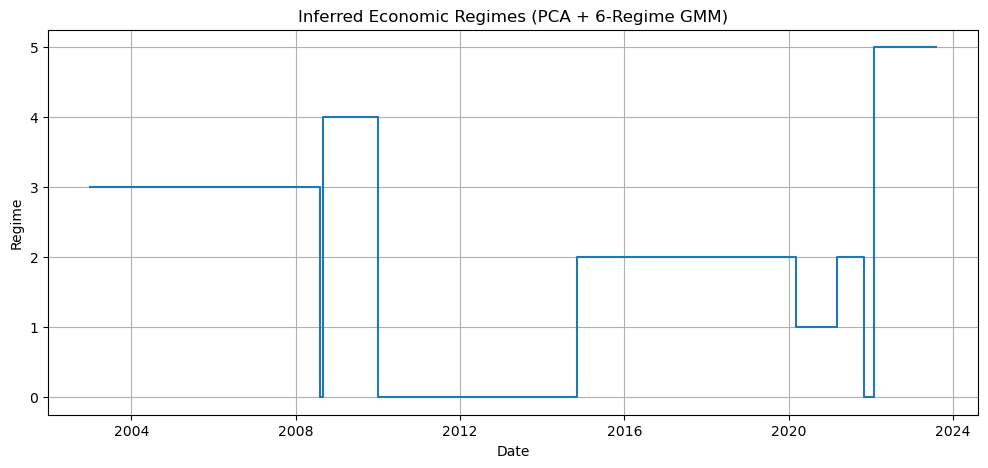

In [85]:
# Plot Regime Transitions Over Time
plt.figure(figsize=(12, 5))
plt.plot(X_regime.index, X_regime['Regime_GMM_PCA'], drawstyle='steps-post')
plt.title('Inferred Economic Regimes (PCA + 6-Regime GMM)')
plt.xlabel('Date')
plt.ylabel('Regime')
plt.grid(True)
plt.show()

### Economic Regime Summary (PCA + 6-Regime GMM)

| Period | Regime | Interpretation |
|:-------|:-------|:---------------|
| 2003 – 2007 | 3 | Pre-crisis expansion with moderate inflation and rising yields. |
| 2008 – 2009 | 4 | Global Financial Crisis — sharp contraction, risk aversion, and monetary easing. |
| 2010 – 2014 | 0 | Recovery phase supported by quantitative easing and accommodative policy. |
| 2015 – 2019 | 2 | Stable growth and normalization period with low inflation. |
| 2020 – 2021 | 1 | COVID-19 disruption, rate cuts, and extreme market dislocation. |
| 2022 – Now | 5 | Inflation resurgence, tightening cycle, and elevated volatility. |

**Summary:**  
The 6-regime PCA + GMM model refines the earlier 4-regime classification by distinguishing more granular macro transitions — especially around 2008, 2015, and 2020.  
This approach better captures shifts between expansion, crisis, recovery, and inflationary phases, revealing finer temporal dynamics in macroeconomic regimes.

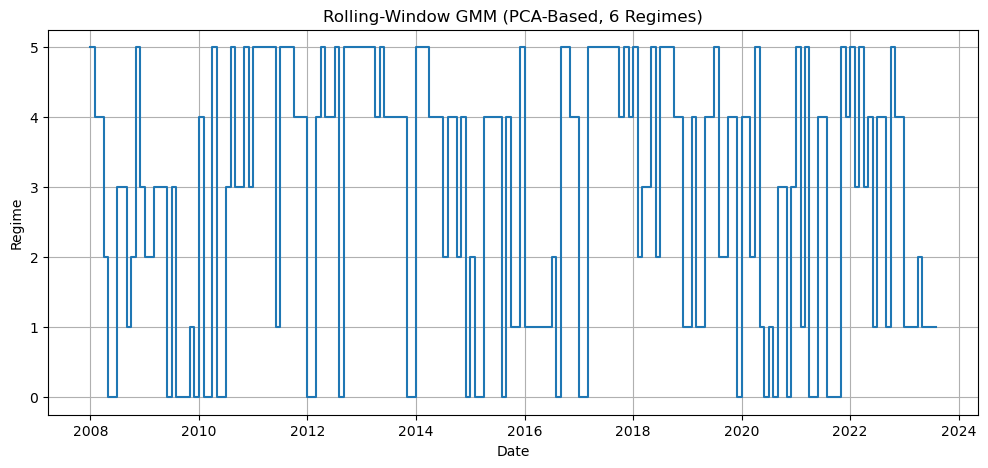

In [87]:
# --- Rolling Diagnostics ---
window_size = 60  # 5 years of data
rolling_labels = []

for i in range(window_size, len(X_pca_df)):
    X_window = X_pca_df.iloc[i - window_size:i]
    gmm = GaussianMixture(n_components=6, random_state=42)
    gmm.fit(X_window)
    regime = gmm.predict(X_pca_df.iloc[i:i+1])[0]
    rolling_labels.append(regime)

rolling_regime_series = pd.Series(rolling_labels, index=X_pca_df.index[window_size:], name='Rolling_Regime_GMM_PCA')

X_regime = X_regime.merge(rolling_regime_series, left_index=True, right_index=True, how='left')

# Plot rolling regimes
plt.figure(figsize=(12, 5))
plt.plot(X_regime.index, X_regime['Rolling_Regime_GMM_PCA'], drawstyle='steps-post')
plt.title('Rolling-Window GMM (PCA-Based, 6 Regimes)')
plt.xlabel('Date')
plt.ylabel('Regime')
plt.grid(True)
plt.show()

### Rolling-Window Diagnostics (PCA + 6-Regime GMM)

To evaluate the temporal stability of the PCA-based regime model, a 60-month (5-year) rolling GMM was applied.
This test checks how consistently the clustering structure holds when the model is refit on moving time windows.

**Key Observations:**
- The rolling regimes fluctuate more frequently, reflecting localized economic changes and model sensitivity to new data.
- Periods of stable clustering (e.g., 2010–2015, 2017–2019) indicate coherent macroeconomic conditions.
- Frequent regime shifts post-2020 align with heightened market volatility and structural disruptions caused by the COVID-19 shock and subsequent tightening cycles.

**Takeaway:**
The rolling diagnostics confirm that while the 6-regime GMM captures major macro transitions, its temporal consistency weakens during periods of market turbulence — validating the need for dynamic regime awareness in forecasting models.

In [89]:
print(X_regime.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 248 entries, 2003-01-01 to 2023-08-01
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CPI                        248 non-null    float64
 1   INDPRO                     248 non-null    float64
 2   VIX                        248 non-null    float64
 3   T10YIE                     248 non-null    float64
 4   GS10                       248 non-null    float64
 5   SP500                      248 non-null    float64
 6   TLT                        248 non-null    float64
 7   Inflation_Uncertainty_10y  248 non-null    float64
 8   Inflation_10y              248 non-null    float64
 9   Real_Yield_10y             248 non-null    float64
 10  INDPRO_YoY_Growth          248 non-null    float64
 11  Regime_GMM                 248 non-null    int64  
 12  Regime_GMM_PCA             248 non-null    int64  
 13  Rolling_Regime_GMM_PCA     188 

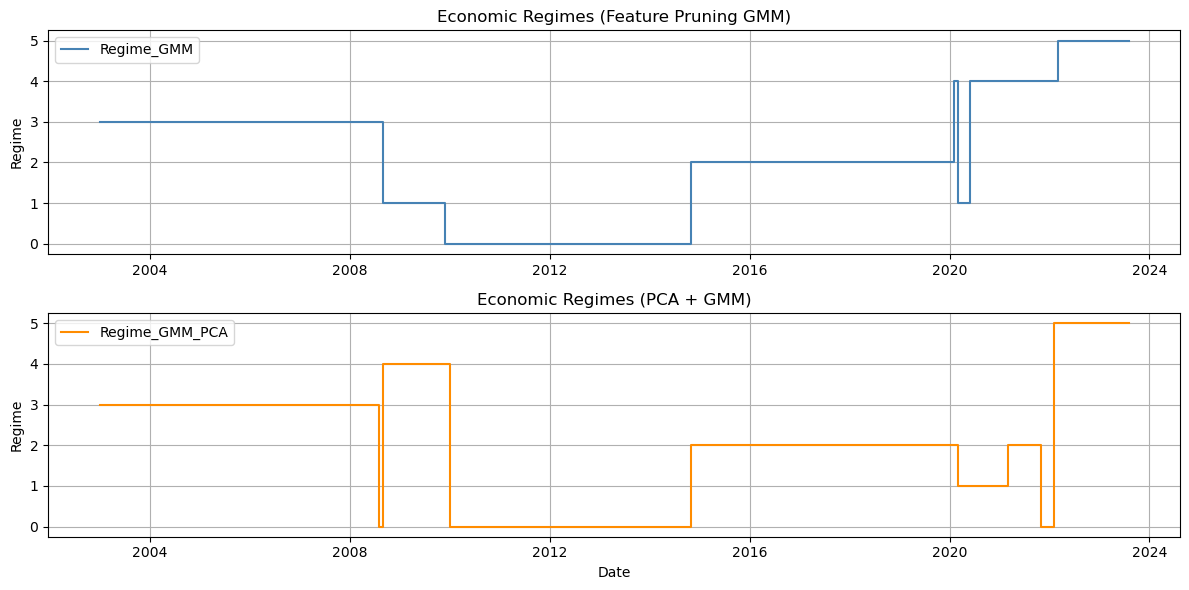

In [97]:
# Compare Static vs. PCA-based Regimes

plt.figure(figsize=(12, 6))

# Plot 1: Static GMM (Feature Pruning Only)
plt.subplot(2, 1, 1)
plt.plot(X_regime.index, X_regime['Regime_GMM'], drawstyle='steps-post', color='steelblue', label='Regime_GMM')
plt.title('Economic Regimes (Feature Pruning GMM)')
plt.ylabel('Regime')
plt.grid(True)
plt.legend()

# Plot 2: PCA-based GMM
plt.subplot(2, 1, 2)
plt.plot(X_regime.index, X_regime['Regime_GMM_PCA'], drawstyle='steps-post', color='darkorange', label='Regime_GMM_PCA')
plt.title('Economic Regimes (PCA + GMM)')
plt.xlabel('Date')
plt.ylabel('Regime')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## Comparison of Regime Classification Methods

I have evaluated two approaches to classify economic regimes using macroeconomic indicators.

| Method | Dimensionality Reduction | Clustering | Features Used | Comments |
|--------|---------------------------|-------------|----------------|-----------|
| **1. Feature-Pruned GMM** | None (manual correlation-based filtering) | GMM (6 components) | 9 macro variables after removing SP500 and GS10 | High interpretability and aligns with economic events, but may discard subtle signals |
| **2. PCA + GMM** | PCA (95% variance retained) | GMM (6 components) | 5 principal components | Noise-reduced and more compact, but less interpretable |

---

### Observations from Results

#### Feature-Pruned GMM
- Clearer regime boundaries with fewer short-term fluctuations.  
- Regimes align well with major macro events (2008 crisis, 2020 COVID, 2022 inflation).  
- Uses original indicators — easy to explain and connect with macroeconomic context.  
- Simpler but might miss nuanced relationships due to feature reduction.  

#### PCA + GMM
- Produces smoother transitions and captures finer dynamics.  
- Automatically handles collinearity and variance concentration.  
- Slightly more reactive, introducing additional short-term regime changes.  
- Less interpretable because PCA components are abstract combinations of features.  

---

### Why Feature-Pruned GMM Performs Better

- **Interpretability:** Maintains direct connection between input features and macro meaning.  
- **Regime Stability:** Fewer erratic shifts and smoother long-term patterns.  
- **Economic Coherence:** Transitions align with known structural shifts (QE era, pandemic, inflation cycle).  
- **Reduced Overfitting:** Avoids reacting to minor fluctuations preserved in PCA variance.  

---

### Final Conclusion

Continue with the **Feature-Pruned GMM** as the **primary regime classification** method for forecasting.  
It delivers a stable, interpretable segmentation that reflects real-world macroeconomic cycles.  
Use **PCA + GMM** only as a **robustness check** to confirm that model outcomes remain consistent under dimensionality reduction.

In [106]:
# Print all Regime_PCA values with their corresponding dates
for date, regime in X_regime['Regime_GMM'].items():
    print(f"{date.strftime('%Y-%m-%d')} : Regime {regime}")

2003-01-01 : Regime 3
2003-02-01 : Regime 3
2003-03-01 : Regime 3
2003-04-01 : Regime 3
2003-05-01 : Regime 3
2003-06-01 : Regime 3
2003-07-01 : Regime 3
2003-08-01 : Regime 3
2003-09-01 : Regime 3
2003-10-01 : Regime 3
2003-11-01 : Regime 3
2003-12-01 : Regime 3
2004-01-01 : Regime 3
2004-02-01 : Regime 3
2004-03-01 : Regime 3
2004-04-01 : Regime 3
2004-05-01 : Regime 3
2004-06-01 : Regime 3
2004-07-01 : Regime 3
2004-08-01 : Regime 3
2004-09-01 : Regime 3
2004-10-01 : Regime 3
2004-11-01 : Regime 3
2004-12-01 : Regime 3
2005-01-01 : Regime 3
2005-02-01 : Regime 3
2005-03-01 : Regime 3
2005-04-01 : Regime 3
2005-05-01 : Regime 3
2005-06-01 : Regime 3
2005-07-01 : Regime 3
2005-08-01 : Regime 3
2005-09-01 : Regime 3
2005-10-01 : Regime 3
2005-11-01 : Regime 3
2005-12-01 : Regime 3
2006-01-01 : Regime 3
2006-02-01 : Regime 3
2006-03-01 : Regime 3
2006-04-01 : Regime 3
2006-05-01 : Regime 3
2006-06-01 : Regime 3
2006-07-01 : Regime 3
2006-08-01 : Regime 3
2006-09-01 : Regime 3
2006-10-01

# Regime Definitions Based on GMM (Feature-Pruned Data)

| Period              | Regime | Name                     | Interpretation |
|----------------------|:------:|------------------------------------|----------------|
| 2003-01 to 2008-08  | 3 | **Pre-GFC Expansion** | Strong growth phase marked by easy credit, rising equities, and housing boom. Low volatility, accommodative monetary policy. |
| 2008-09 to 2009-11  | 1 | **Global Financial Crisis (GFC)** | Severe contraction triggered by financial market collapse, liquidity crisis, and deleveraging. |
| 2009-12 to 2014-10  | 0 | **Post-Crisis QE Recovery** | Stabilization under Quantitative Easing; near-zero interest rates; gradual market rebound. |
| 2014-11 to 2020-01  | 2 | **Low-Inflation Expansion** | Synchronized global growth, fiscal stimulus, rising corporate profits; muted inflation. |
| 2020-02             | 4 | **COVID Pre-Shock Pivot** | Early market stress preceding full pandemic onset; liquidity squeeze and rate cuts. |
| 2020-03 to 2020-05  | 1 | **COVID Market Collapse** | Sharp downturn during initial pandemic lockdowns; policy panic, market selloff. |
| 2020-06 to 2022-02  | 4 | **COVID Policy Support & Recovery** | Rapid rebound from unprecedented fiscal and monetary stimulus; asset price surge. |
| 2022-03 to Present  | 5 | **Inflation & Tightening Cycle** | High inflation, aggressive Fed rate hikes, quantitative tightening, and elevated yields. |

In [110]:
# Ensure index is Timestamp (month-start)
X_regime = X_regime.copy()
if not isinstance(X_regime.index, pd.DatetimeIndex):
    X_regime.index = pd.to_datetime(X_regime.index)

# Helper to build labels from (start, end, regime_id, name)
def _apply_named_windows(df, col, windows):
    labels = pd.Series(index=df.index, dtype="object")
    for start, end, r, name in windows:
        mask = (df.index >= start) & (df.index <= end) & (df[col] == r)
        labels.loc[mask] = name
    # anything unmatched (rare anomalies) → Transition/Other
    labels.fillna("Transition/Other", inplace=True)
    return labels

# --- Final timeline from your GMM (feature-pruned) results ---
windows = [
    # (start, end, regime_id, "label")
    (pd.Timestamp("2003-01-01"), pd.Timestamp("2008-08-01"), 3, "Pre-GFC Expansion"),
    (pd.Timestamp("2008-09-01"), pd.Timestamp("2009-11-01"), 1, "Global Financial Crisis (GFC)"),
    (pd.Timestamp("2009-12-01"), pd.Timestamp("2014-10-01"), 0, "Post-Crisis QE Recovery"),
    (pd.Timestamp("2014-11-01"), pd.Timestamp("2020-01-01"), 2, "Low-Inflation Expansion"),
    (pd.Timestamp("2020-02-01"), pd.Timestamp("2020-02-01"), 4, "COVID Pre-Shock Pivot"),
    (pd.Timestamp("2020-03-01"), pd.Timestamp("2020-05-01"), 1, "COVID Market Collapse"),
    (pd.Timestamp("2020-06-01"), pd.Timestamp("2022-02-01"), 4, "COVID Policy Support & Recovery"),
    (pd.Timestamp("2022-03-01"), pd.Timestamp("2100-01-01"), 5, "Inflation & Tightening Cycle"),
]

# Apply
X_regime["Regime_Name"] = _apply_named_windows(X_regime, "Regime_GMM", windows)

# Quick check
print(X_regime[["Regime_GMM", "Regime_Name"]].head(12))
print(X_regime[["Regime_GMM", "Regime_Name"]].loc["2019":"2020"].head(12))
print(X_regime[["Regime_GMM", "Regime_Name"]].tail(6))

            Regime_GMM        Regime_Name
date                                     
2003-01-01           3  Pre-GFC Expansion
2003-02-01           3  Pre-GFC Expansion
2003-03-01           3  Pre-GFC Expansion
2003-04-01           3  Pre-GFC Expansion
2003-05-01           3  Pre-GFC Expansion
2003-06-01           3  Pre-GFC Expansion
2003-07-01           3  Pre-GFC Expansion
2003-08-01           3  Pre-GFC Expansion
2003-09-01           3  Pre-GFC Expansion
2003-10-01           3  Pre-GFC Expansion
2003-11-01           3  Pre-GFC Expansion
2003-12-01           3  Pre-GFC Expansion
            Regime_GMM              Regime_Name
date                                           
2019-01-01           2  Low-Inflation Expansion
2019-02-01           2  Low-Inflation Expansion
2019-03-01           2  Low-Inflation Expansion
2019-04-01           2  Low-Inflation Expansion
2019-05-01           2  Low-Inflation Expansion
2019-06-01           2  Low-Inflation Expansion
2019-07-01           2  Low-

In [112]:
print(X_regime.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 248 entries, 2003-01-01 to 2023-08-01
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   CPI                              248 non-null    float64
 1   INDPRO                           248 non-null    float64
 2   VIX                              248 non-null    float64
 3   T10YIE                           248 non-null    float64
 4   GS10                             248 non-null    float64
 5   SP500                            248 non-null    float64
 6   TLT                              248 non-null    float64
 7   Inflation_Uncertainty_10y        248 non-null    float64
 8   Inflation_10y                    248 non-null    float64
 9   Real_Yield_10y                   248 non-null    float64
 10  INDPRO_YoY_Growth                248 non-null    float64
 11  Regime_GMM                       248 non-null    int64  
 12  Reg

In [114]:
# Ensure both dataframes have datetime index
final_df = final_df.copy()
final_df.index = pd.to_datetime(final_df.index)
X_regime.index = pd.to_datetime(X_regime.index)

# Merge regime info (Regime_GMM and Regime_Name) into final_df
final_df = final_df.merge(
    X_regime[['Regime_GMM', 'Regime_Name']],
    left_index=True,
    right_index=True,
    how='left'
)

# Rename columns for clarity
final_df.rename(columns={
    'Regime_GMM': 'Regime',
    'Regime_Name': 'Regime_Name'
}, inplace=True)

# Quick check
print(final_df.info())
print(final_df[['Regime', 'Regime_Name']].head(10))

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 248 entries, 2003-01-01 to 2023-08-01
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CPI                        248 non-null    float64
 1   INDPRO                     248 non-null    float64
 2   VIX                        248 non-null    float64
 3   T10YIE                     248 non-null    float64
 4   GS10                       248 non-null    float64
 5   SP500                      248 non-null    float64
 6   TLT                        248 non-null    float64
 7   Inflation_Uncertainty_10y  248 non-null    float64
 8   Inflation_10y              248 non-null    float64
 9   Real_Yield_10y             248 non-null    float64
 10  INDPRO_YoY_Growth          248 non-null    float64
 11  SP500_TLT_Corr_24m_fl      248 non-null    float64
 12  sentiment                  248 non-null    float64
 13  sentiment_lag_1m           247 

In [116]:
macro_regime_labeled_path = os.path.join(macro_directory, "macro_full_df_regime.csv")

final_df.to_csv(macro_regime_labeled_path)
print(f"Saved regime labeled macro data to: {macro_regime_labeled_path}")

Saved regime labeled macro data to: /Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Data/macro/macro_full_df_regime.csv
